# SEM degradation augmentation

Reproduce the noise/contrast profile of low-quality SEM images (e.g. Wilson set) and apply it to clean HQ images for data augmentation.

Pipeline per image: mild Gaussian blur -> contrast compression to a target (mean, std) -> additive Gaussian noise -> sparse bright speckles.

The target parameters are estimated from a reference directory of degraded images, so the pipeline adapts to whatever "bad" set you point it at.

In [2]:
import os
from dataclasses import dataclass

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


def _iter_gray(dir_path, pred=None):
    for fname in sorted(os.listdir(dir_path)):
        if not fname.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):
            continue
        if pred is not None and not pred(fname):
            continue
        im = cv2.imread(os.path.join(dir_path, fname), cv2.IMREAD_GRAYSCALE)
        if im is not None:
            yield fname, im


def _immerkaer_sigma(img):
    """Robust noise std estimate (Immerkaer 1996).
    Uses the fact that convolving with a Laplacian-of-Laplacian kernel
    cancels out smooth content and leaves noise, scaled by a known factor."""
    img = img.astype(np.float64)
    M = np.array([[ 1, -2,  1],
                  [-2,  4, -2],
                  [ 1, -2,  1]], dtype=np.float64)
    conv = convolve2d(img, M, mode="valid")
    H, W = conv.shape
    return float(np.sqrt(np.pi / 2) * np.abs(conv).sum() / (6.0 * W * H))


def _denoise(img):
    """Strong edge-preserving denoise to recover the underlying signal."""
    return cv2.fastNlMeansDenoising(img, None, h=12, templateWindowSize=7, searchWindowSize=21)


In [3]:
from dataclasses import dataclass


@dataclass
class DegradationProfile:
    signal_mean: float       # target mean intensity (of the clean signal)
    signal_std: float        # target std of the clean signal (lower => less contrast)
    noise_sigma: float       # target total noise std (Immerkaer)
    speckle_rate: float      # fraction of pixels flipped to a bright speckle
    speckle_value: float     # mean intensity of bright speckles (0-255)

    @classmethod
    def estimate(cls, ref_dir, pred=None, max_images=16, speckle_threshold=40):
        """Fit a profile from a directory of reference images.

        signal_* are measured on a denoised copy so texture is excluded.
        speckle_rate counts pixels far brighter than the local signal (charge-up spots),
        and speckle_value is their mean intensity.
        """
        noise_sigmas, means, stds, speckle_frac, speckle_val = [], [], [], [], []
        for i, (_, im) in enumerate(_iter_gray(ref_dir, pred)):
            if i >= max_images:
                break
            noise_sigmas.append(_immerkaer_sigma(im))
            clean = _denoise(im)
            means.append(float(clean.mean()))
            stds.append(float(clean.std()))
            residual = im.astype(np.int32) - clean.astype(np.int32)
            mask = residual > speckle_threshold
            speckle_frac.append(float(mask.mean()))
            if mask.any():
                speckle_val.append(float(im[mask].mean()))
        if not noise_sigmas:
            raise ValueError(f"no images matched in {ref_dir}")
        return cls(
            signal_mean=float(np.mean(means)),
            signal_std=float(np.mean(stds)),
            noise_sigma=float(np.mean(noise_sigmas)),
            speckle_rate=float(np.mean(speckle_frac)),
            speckle_value=float(np.mean(speckle_val)) if speckle_val else 200.0,
        )

    def summary(self):
        return (f"mean={self.signal_mean:.1f}  std={self.signal_std:.2f}  "
                f"noise_sigma={self.noise_sigma:.2f}  "
                f"speckle_rate={self.speckle_rate*100:.3f}%  "
                f"speckle_value={self.speckle_value:.0f}")


In [4]:
REF_DIR   = "Images/cropped_alumina_imperfect_doped"   # directory that contains degraded images
REF_PRED  = lambda f: "Wilson" in f                      # pick only Wilson-labeled images
CLEAN_DIR = "Images/cropped_alumina_highquality"        # source of clean images to be degraded

target   = DegradationProfile.estimate(REF_DIR, pred=REF_PRED)
baseline = DegradationProfile.estimate(CLEAN_DIR)
print(f"target   (Wilson) : {target.summary()}")
print(f"baseline (HQ)     : {baseline.summary()}")


target   (Wilson) : mean=72.3  std=10.06  noise_sigma=11.80  speckle_rate=0.057%  speckle_value=121
baseline (HQ)     : mean=83.8  std=10.58  noise_sigma=7.71  speckle_rate=0.000%  speckle_value=135


In [5]:
def _resize(img, scale, interp):
    h, w = img.shape[:2]
    return cv2.resize(img, (max(1, int(round(w * scale))), max(1, int(round(h * scale)))),
                      interpolation=interp)


def _tile_with_random_flips(small, H, W, rng):
    """Tile `small` to cover (H, W) with independent random flips per tile.

    Random flips break the perfect mirror-symmetry that strict alternating
    reflection would produce, which the model could otherwise learn to detect.
    Seams are still visible at tile boundaries; mitigated somewhat by the flips.
    """
    sh, sw = small.shape[:2]
    ny = int(np.ceil(H / sh))
    nx = int(np.ceil(W / sw))
    rows = []
    for _ in range(ny):
        row_tiles = []
        for _ in range(nx):
            t = small
            if rng.random() < 0.5: t = np.flip(t, axis=0)
            if rng.random() < 0.5: t = np.flip(t, axis=1)
            row_tiles.append(t)
        rows.append(np.concatenate(row_tiles, axis=1))
    return np.concatenate(rows, axis=0)[:H, :W]


def _rescale_grains(img, scale, mode, rng):
    """Change the apparent grain size in the output.

    mode='tile'    (for scale < 1): downsample to `scale`x, then tile with random
                    flips back to (h, w). Makes grains visibly smaller; may leave
                    faint tile seams.
    mode='downup'  (for scale < 1): downsample then upsample back. Grains stay
                    the same size; simulates resolution / MTF loss only. No seams.
    mode='zoom'    (for scale > 1): upsample then random-crop. Grains appear larger.
    """
    if scale == 1.0:
        return img
    h, w = img.shape[:2]
    if scale > 1.0:
        big = _resize(img, scale, cv2.INTER_CUBIC)
        bh, bw = big.shape[:2]
        y0 = int(rng.integers(0, bh - h + 1))
        x0 = int(rng.integers(0, bw - w + 1))
        return big[y0:y0 + h, x0:x0 + w]
    small = _resize(img, scale, cv2.INTER_AREA)
    if mode == 'downup':
        return cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
    if mode == 'tile':
        return _tile_with_random_flips(small, h, w, rng)
    raise ValueError(f"unknown mode {mode!r}")


def degrade(img, target, baseline=None, blur_sigma=0.8,
            resolution_scale=1.0, resolution_mode='tile', rng=None):
    """Apply SEM-like degradation to `img` so its stats approximate `target`.

    `resolution_scale`/`resolution_mode` control apparent grain size.
    If `baseline` is given, only the noise delta above the clean image's own noise is added.
    """
    rng = rng or np.random.default_rng()

    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # 0. Rescale grain size.
    gray = _rescale_grains(gray, resolution_scale, resolution_mode, rng)
    work = gray.astype(np.float32)

    # 1. Mild Gaussian blur (microscope PSF).
    if blur_sigma and blur_sigma > 0:
        k = max(3, int(2 * round(3 * blur_sigma) + 1))
        work = cv2.GaussianBlur(work, (k, k), blur_sigma)

    # 2. Contrast compression: rescale so (mean, std) match the target signal.
    src_mean = float(work.mean())
    src_std  = float(work.std()) or 1.0
    scale = target.signal_std / src_std
    work = (work - src_mean) * scale + target.signal_mean

    # 3. Additive Gaussian noise -- only the delta above the clean image's own noise.
    if baseline is not None:
        extra_var = max(target.noise_sigma ** 2 - baseline.noise_sigma ** 2, 0.0)
        noise_sigma = float(np.sqrt(extra_var))
    else:
        noise_sigma = target.noise_sigma
    if noise_sigma > 0:
        work = work + rng.normal(0.0, noise_sigma, work.shape).astype(np.float32)

    # 4. Sparse bright speckles (charge-up spots).
    if target.speckle_rate > 0:
        mask = rng.random(work.shape) < target.speckle_rate
        work[mask] = target.speckle_value + rng.normal(0, 5, size=mask.sum())

    work = np.clip(work, 0, 255).astype(np.uint8)
    if img.ndim == 3:
        return cv2.cvtColor(work, cv2.COLOR_GRAY2BGR)
    return work


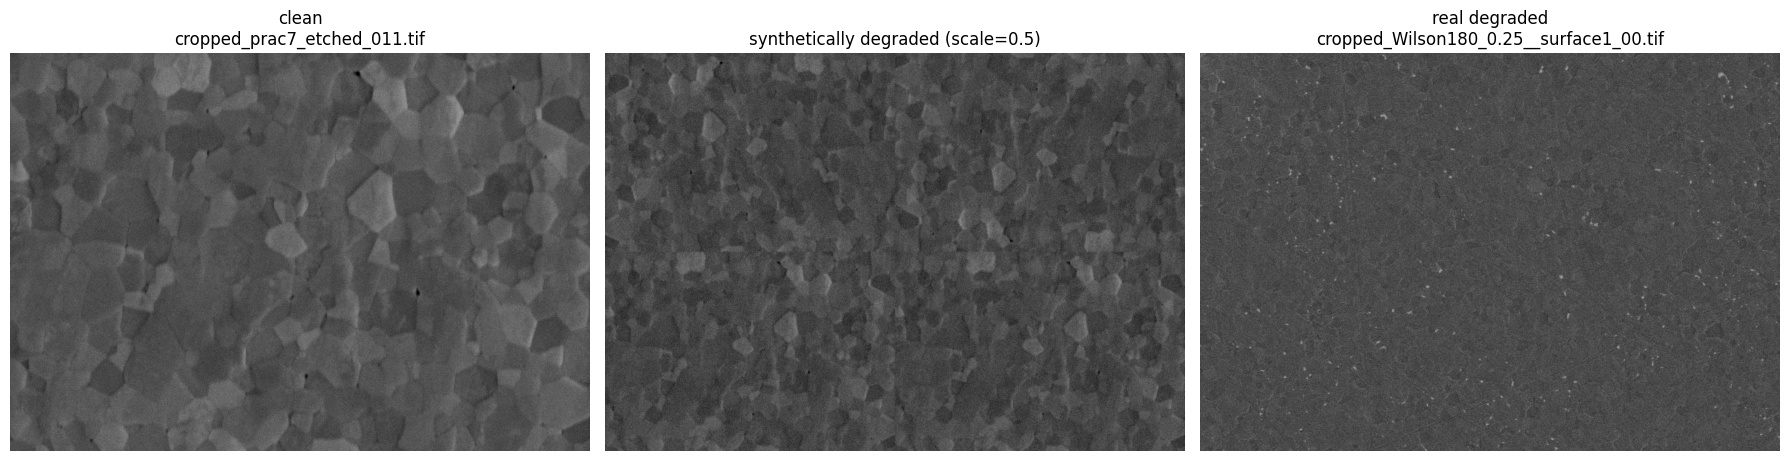

degraded stats: 9.003683420914257 71.87502778271693 13.506206621322617
ref      stats: 8.960238922559371 75.36594839082504 10.903662860751997


In [6]:
rng = np.random.default_rng(0)

BLUR_SIGMA       = 0.8
RESOLUTION_SCALE = 0.5     # <1.0 tiles a smaller copy, making grains appear smaller
                            # >1.0 zooms in, making grains appear larger
                            #  1.0 keeps grain size unchanged

clean_fname, clean = next(_iter_gray(CLEAN_DIR))
ref_fname,   ref   = next(_iter_gray(REF_DIR, pred=REF_PRED))
degraded = degrade(clean, target, baseline=baseline,
                   blur_sigma=BLUR_SIGMA, resolution_scale=RESOLUTION_SCALE, rng=rng)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(clean,    cmap="gray", vmin=0, vmax=255); ax[0].set_title(f"clean\n{clean_fname}")
ax[1].imshow(degraded, cmap="gray", vmin=0, vmax=255); ax[1].set_title(f"synthetically degraded (scale={RESOLUTION_SCALE})")
ax[2].imshow(ref,      cmap="gray", vmin=0, vmax=255); ax[2].set_title(f"real degraded\n{ref_fname}")
for a in ax: a.axis("off")
plt.tight_layout()
plt.show()

print("degraded stats:", _immerkaer_sigma(degraded), degraded.mean(), degraded.std())
print("ref      stats:", _immerkaer_sigma(ref),      ref.mean(),      ref.std())


In [7]:
OUT_DIR = "Images/cropped_alumina_highquality_degraded"
os.makedirs(OUT_DIR, exist_ok=True)

# If you want a spread of grain-size effects in the training set, sample
# resolution_scale per image from a range rather than fixing one value.
SCALE_CHOICES = [0.4, 0.5, 0.65, 0.85, 1.0]

rng = np.random.default_rng(42)
n = 0
for fname, im in _iter_gray(CLEAN_DIR):
    s = float(rng.choice(SCALE_CHOICES))
    out = degrade(im, target, baseline=baseline,
                  blur_sigma=0.8, resolution_scale=s, rng=rng)
    cv2.imwrite(os.path.join(OUT_DIR, fname), out)
    n += 1
print(f"wrote {n} degraded images to {OUT_DIR}")


wrote 91 degraded images to Images/cropped_alumina_highquality_degraded
